MAKING A LINEAR REGRESSION MODEL FOR HOUSING PRICES

IMPORTING LIBRARIES NECESSARY

In [1]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt

Inputting the training data

In [2]:
x_train=np.array(sorted(random.sample(range(1,10),5)))   #x_train is the size in sqft 100000
y_train=np.array(sorted(random.sample(range(30,90),5))) #y_train is the price of teh hosue in dollars
#x_train=np.array([1,2])
#y_train=np.array([1200,3000])
print(f"x_train={x_train}")
print(f"y_train={y_train}")

x_train=[2 3 4 8 9]
y_train=[37 80 85 88 89]


Confirming the shape and size of the input and the test result samples. m is the number of training samples

In [3]:
#m is the number of trainning samples
print(f"x_train.shape:{x_train.shape}")
m=x_train.shape[0]                      # .shape[0]gives teh length of the array
print(f"The number of training examples is:{m}")

x_train.shape:(5,)
The number of training examples is:5


Plot the samples on a graph

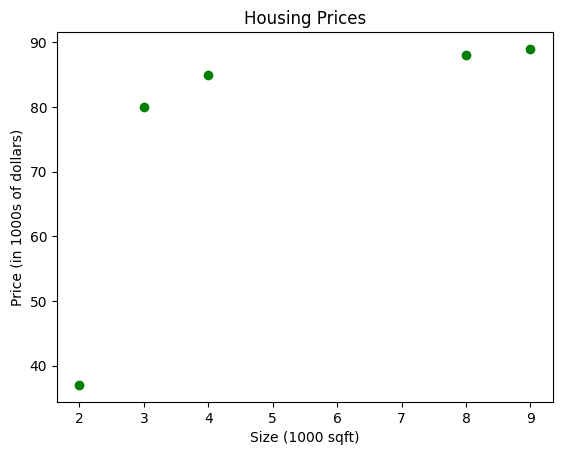

In [4]:
# Plot the data points
plt.scatter(x_train, y_train, marker="o",c='g')
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.show()

Computing the cost function for the model. we are using the square mean formula.Image is there in AI projects folder


In [5]:
def compute_cost(x,y,w,b):
    m=x.shape[0]
    cost=0
    for i in range (m):
        cost+=((w*x[i]+b)-y[i])**2    #cost=sigma(from i=1 toi=m) (f(x[i])-y[i])^2
    cost_final=cost/2*m
    return cost_final 

Now making the gradient descent function to reduce the cost.Again the theory is in AI projects
We start with finding the gradient 

In [6]:
def compute_gradient(x,y,w,b):
    m=x.shape[0]
    dj_dw,dj_db=0,0   #this is variable names for partial  derivatives for J(cost function) wrt w and J wrt b
    for i in range (m):
        dj_dw+=((w*x[i]+b)-y[i])*(x[i])
        dj_db+=((w*x[i]+b)-y[i])
    dj_dw=dj_dw/m
    dj_db=dj_db/m
    return dj_dw,dj_db

Now we try to find the gradient descent.

In [7]:
def gradient_descent(x,y,w,b,alpha,num_itera):
    for i in range (num_itera):
        dj_dw,dj_db=compute_gradient(x,y,w,b)
        #Update parameter each time
        w-=alpha*dj_dw
        b-=alpha*dj_db
        #print iteration numbers 10% of the time
        if i%math.ceil(num_itera/10)==0:
            print(f"iteration number {i}: Cost {compute_cost(x,y,w,b)}: ",
              f"dj_dw {dj_dw}: dj_db {dj_db}: ",
              f"w: {w}, b:{b}")
    return w,b   

Now we just initialize everything and pot result into the graph.

In [8]:
#initialize parameters
w=0
b=0
#setting the hyperparameters
iterations=10000
alpha=0.01
print(f"w:{w}",f"b:{b}",f"number of iterations:{iterations}",f"alpha:{alpha}")
#run gradient descent
w,b= gradient_descent(x_train,y_train,w,b,alpha,iterations)
print(f"The values of w and b found using gradient descent are: w:{w:8.4f} and b:{b:8.4f}")

w:0 b:0 number of iterations:10000 alpha:0.01
iteration number 0: Cost 37141.586709999996:  dj_dw -431.8: dj_db -75.8:  w: 4.3180000000000005, b:0.758
iteration number 1000: Cost 2628.560486804368:  dj_dw 0.18011257110847795: dj_db -1.1978148121483927:  w: 5.674584131283776, b:45.09695999959982
iteration number 2000: Cost 2545.8954195354936:  dj_dw 0.02029383356379242: dj_db -0.13496145376410168:  w: 4.943365797893372, b:49.959830732382684
iteration number 3000: Cost 2544.8459685484117:  dj_dw 0.0022865682177695135: dj_db -0.015206519252721762:  w: 4.860977194669874, b:50.50774523210914
iteration number 4000: Cost 2544.8326455401484:  dj_dw 0.0002576346257313844: dj_db -0.0017133649744721425:  w: 4.851694219078096, b:50.56948043246863
iteration number 5000: Cost 2544.8324764016643:  dj_dw 2.9028480255988143e-05: dj_db -0.00019305006537706504:  w: 4.850648277862133, b:50.57643632607121
iteration number 6000: Cost 2544.832474254415:  dj_dw 3.2707275437360296e-06: dj_db -2.175154056374140

Now we can make the final graph of the line.

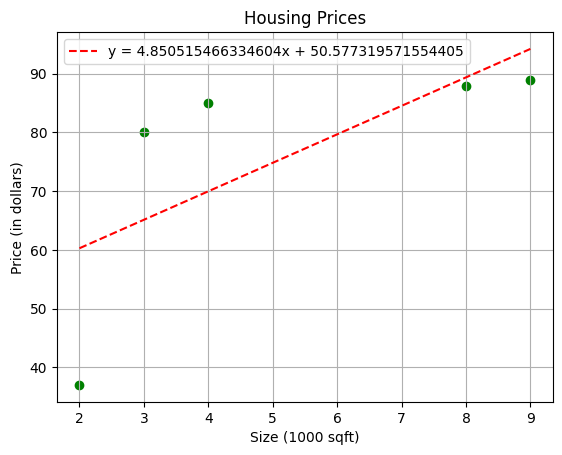

In [9]:
# Plot the data points
plt.scatter(x_train, y_train, marker="o",c='g')
# Plot the known line: y = mx + b
m = w  # slope
b = b  # y-intercept
x_line = np.array([min(x_train), max(x_train)])  # Use same range as data
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red', linestyle='--', label=f'y = {m}x + {b}')

# Labels and legend
plt.title("Housing Prices")
plt.xlabel("Size (1000 sqft)")
plt.ylabel("Price (in dollars)")
plt.legend()
plt.grid(True)
plt.show()

We can also make predictions based on this model.